<a href="https://colab.research.google.com/github/aniq63/Airbnb-NYC-DataAnalytics/blob/main/notebooks/NYC_Aribnb_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Business Objective

Analyze Airbnb listings in New York City to understand the factors associated with listing prices, availability, and customer engagement.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/clean_airbnb_listing.csv')

In [3]:
df.sample(3)

,host_identity_verified,neighbourhood group,lat,long,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
10458,unconfirmed,Brooklyn,40.64130,-73.90303,False,moderate,Private room,2009,675.0,135.0,2,1,0.03,1.0,3,249
57063,verified,Queens,40.68038,-73.77244,False,flexible,Entire home/apt,2016,102.0,20.0,3,42,1.85,2.0,3,348
10501,verified,Brooklyn,40.70400,-73.98464,True,flexible,Private room,2008,670.0,134.0,3,23,0.63,1.0,1,161


In [4]:
df.shape

(57935, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57935 entries, 0 to 57934
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   host_identity_verified          57935 non-null  object 
 1   neighbourhood group             57935 non-null  object 
 2   lat                             57935 non-null  float64
 3   long                            57935 non-null  float64
 4   instant_bookable                57935 non-null  bool   
 5   cancellation_policy             57935 non-null  object 
 6   room type                       57935 non-null  object 
 7   Construction year               57935 non-null  int64  
 8   price                           57935 non-null  float64
 9   service fee                     57935 non-null  float64
 10  minimum nights                  57935 non-null  int64  
 11  number of reviews               57935 non-null  int64  
 12  reviews per month               

In [6]:
# The construction Year of the Airbnb Listing
df['Construction year'].value_counts()

,count
Construction year,
2007,2994
2008,2991
2014,2984
2019,2953
2022,2950
2005,2934
2012,2929
2006,2925
2004,2903


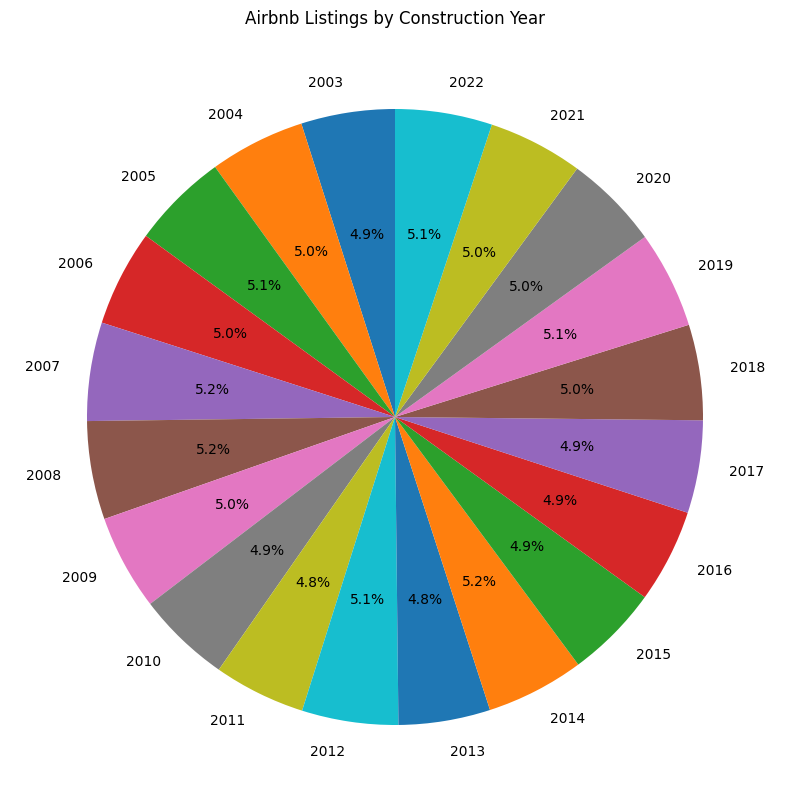

In [7]:
# Count listings for each construction year
construction_counts = df['Construction year'].value_counts().sort_index()

# Plot pie chart
plt.figure(figsize=(10, 10))
plt.pie(
    construction_counts,
    labels=construction_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Airbnb Listings by Construction Year')
plt.show()

In [8]:
df.describe()

,lat,long,Construction year,price,service fee,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
count,57935.000000,57935.000000,57935.000000,57935.000000,57935.000000,57935.000000,57935.000000,57935.000000,57935.000000,57935.000000,57935.000000
mean,40.727592,-73.950255,2012.489411,625.220005,125.044049,2.797756,12.926348,0.865704,3.258117,1.292293,114.721567
std,0.056556,0.047360,5.777905,331.422791,66.287612,1.729365,17.088210,0.838574,1.294702,0.584673,131.043531
min,40.499790,-74.244420,2003.000000,50.000000,10.000000,1.000000,0.000000,0.010000,1.000000,1.000000,-10.000000
25%,40.688420,-73.981280,2007.000000,340.000000,68.000000,1.000000,1.000000,0.220000,2.000000,1.000000,0.000000
50%,40.720210,-73.954070,2012.000000,625.000000,125.000000,2.000000,5.000000,0.740000,3.000000,1.000000,59.000000
75%,40.763205,-73.934285,2018.000000,912.000000,182.000000,4.000000,18.000000,1.090000,4.000000,1.000000,211.000000
max,40.916970,-73.710870,2022.000000,1200.000000,240.000000,9.000000,73.000000,3.850000,5.000000,3.000000,426.000000


**Finding:** Almost every construction year from 2003 to 2022 has around 4,700–4,900 Airbnb listings. It's interesting to see how consistently the listings are spread across construction years.

In [9]:
df.sample(3)

,host_identity_verified,neighbourhood group,lat,long,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
11941,verified,Manhattan,40.73537,-74.00209,True,flexible,Entire home/apt,2009,718.0,144.0,2,57,1.68,4.0,2,22
51875,unconfirmed,Manhattan,40.74252,-73.99100,False,moderate,Entire home/apt,2016,823.0,165.0,1,2,0.07,4.0,1,0
7159,verified,Brooklyn,40.69824,-73.93231,True,flexible,Private room,2009,899.0,180.0,1,0,0.74,5.0,1,127


In [15]:
# Exploring the Categoorical data
print(f"Shape of Categorical data {df.select_dtypes(include ='object').shape}")
for col in df.select_dtypes(include ='object').columns:
  print(col)
  print(df[col].nunique())
  print(df[col].unique())
  print("="*50)

Shape of Categorical data (57935, 4)
host_identity_verified
2
['verified' 'unconfirmed']
neighbourhood group
5
['Manhattan' 'Brooklyn' 'Queens' 'Staten Island' 'Bronx']
cancellation_policy
3
['flexible' 'strict' 'moderate']
room type
4
['Entire home/apt' 'Private room' 'Shared room' 'Hotel room']


### The main Business Question is Pricing , Availabiloty and the Customer Engagement

### Exploring the factor Asscoiated with Pricing

In [22]:
import matplotlib.pyplot as plt


def plot_mean_bars(df, categorical_col, numerical_col):
    """Calculates the mean of a numerical column grouped by a categorical column

    and visualizes it as a bar chart.
    """
    # 1. Calculate the mean and plot directly
    df.groupby(categorical_col)[numerical_col].mean().plot(
        kind="bar", color="skyblue", edgecolor="black"
    )

    # 2. Add labels and styling dynamically using string formatting
    plt.title(
        f"Average {numerical_col} by {categorical_col}",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel(categorical_col, fontsize=12)
    plt.ylabel(f"Average {numerical_col}", fontsize=12)
    plt.xticks(rotation=0)

    # 3. Show the plot
    plt.tight_layout()  # Prevents labels from getting cut off
    plt.show()

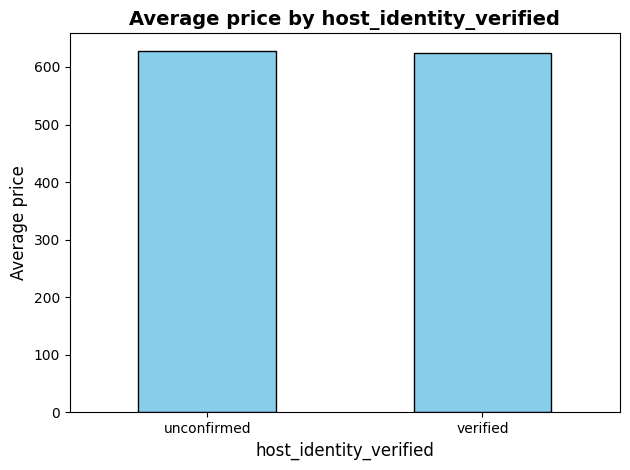

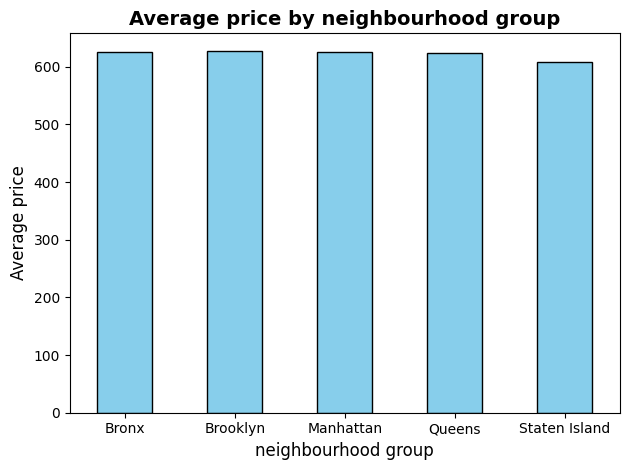

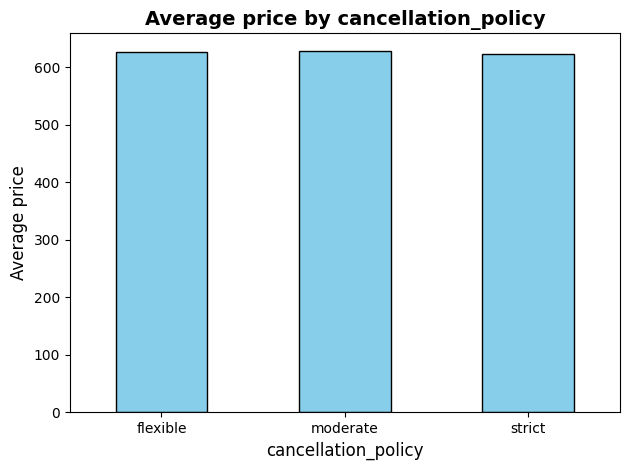

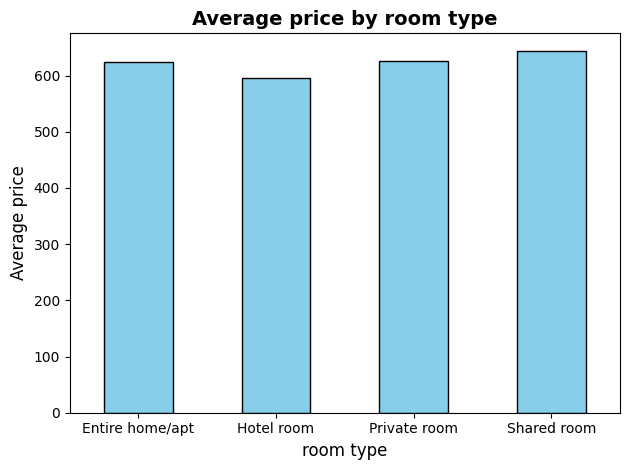

In [23]:
for col in df.select_dtypes(include="object").columns:
  plot_mean_bars(df , col, "price")

**1. Host Identity Verification (`host_identity_verified`)**

* **Observation:** The average price remains virtually identical between **unconfirmed** and **verified** hosts (both hovering right around **620–630**).
* **Impact on Price:** Having a verified host identity does not show a noticeable premium or discount on the average listing price.

**2. Neighbourhood Group (`neighbourhood_group`)**

* **Observation:** Across all major geographic groups (Bronx, Brooklyn, Manhattan, Queens, and Staten Island), the average price stays extremely consistent at roughly **620–630**, with Staten Island showing a very minor dip down to around **610**.
* **Impact on Price:** Location group category alone shows a negligible variance in average pricing within this specific dataset scope, indicating that geographic grouping does not heavily skew the baseline averages here.

**3. Cancellation Policy (`cancellation_policy`)**

* **Observation:** Whether a policy is **flexible**, **moderate**, or **strict**, the average price remains flat at approximately **625**.
* **Impact on Price:** The strictness of the cancellation policy does not influence or dictate the pricing structure of the listings.

**4. Room Type (`room_type`)**

* **Observation:** Categories including **Entire home/apt**, **Hotel room**, **Private room**, and **Shared room** all display nearly uniform average prices ranging tightly between **600 and 650** (with shared rooms tracking slightly higher and hotel rooms slightly lower).
* **Impact on Price:** Counterintuitively, traditional assumptions where entire homes command massive premiums over shared spaces do not heavily reflect in these specific average metrics, as all room types cluster closely together.


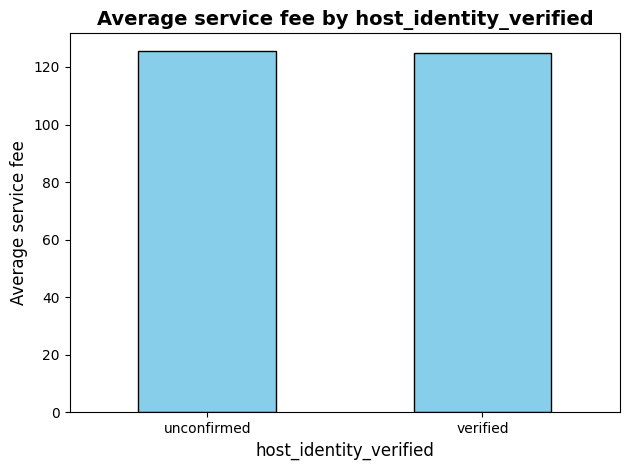

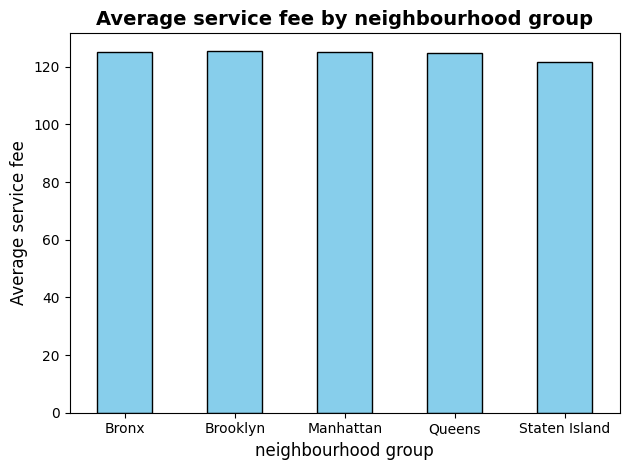

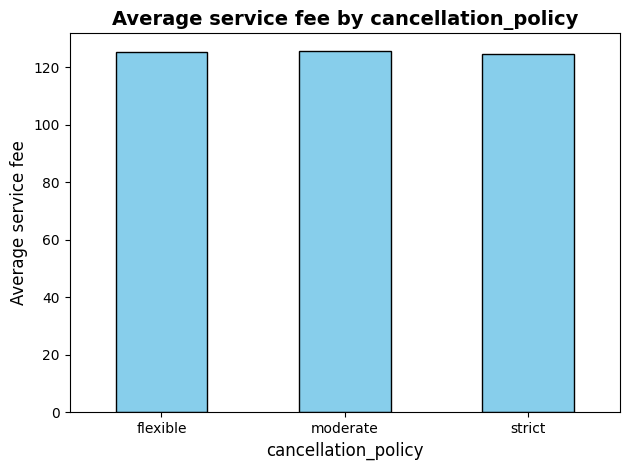

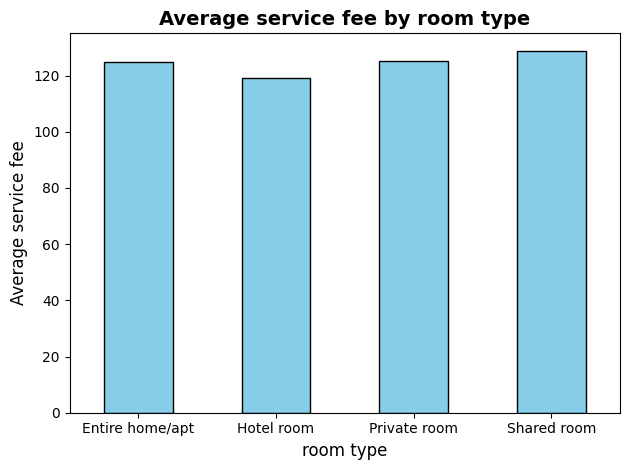

In [24]:
for col in df.select_dtypes(include="object").columns:
  plot_mean_bars(df , col, "service fee")

Shared rooms command the highest average service fee (approx. 129), while Hotel rooms record the lowest (approx. 119). Entire home/apt and Private room sit nearly equal right around 125.

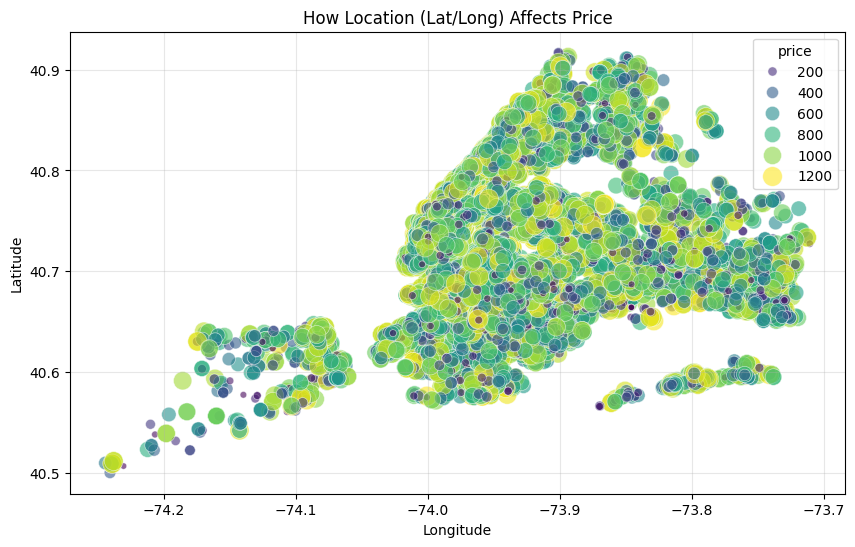

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the spatial scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='long',
    y='lat',
    hue='price',     # Colors points by price
    palette='viridis', # Beautiful color gradient (dark = low, bright = high)
    alpha=0.6,       # Helps see dense areas clearly
    size='price',    # Optional: also makes expensive points physically larger
    sizes=(20, 200)
)

plt.title('How Location (Lat/Long) Affects Price')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, alpha=0.3)
plt.show()

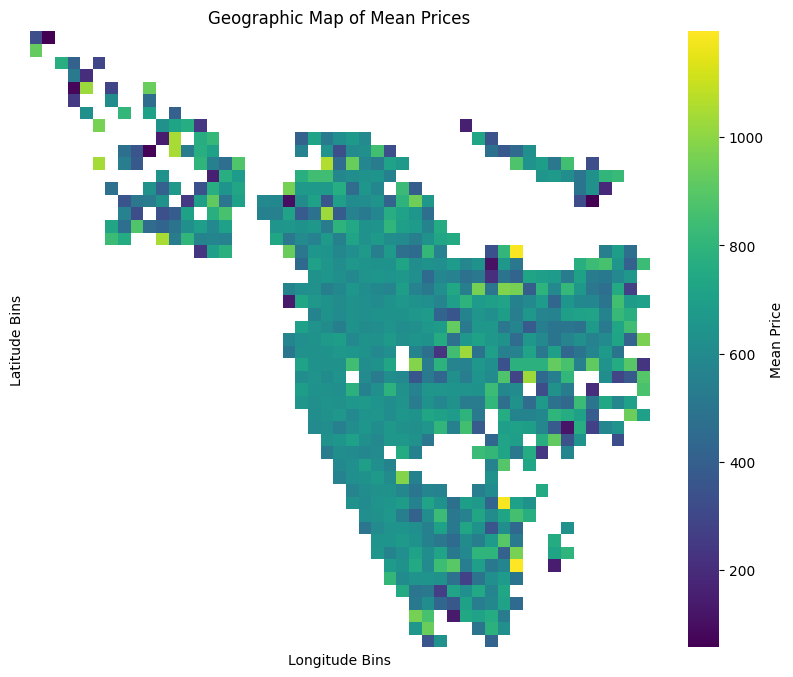

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

# Define bins for latitude and longitude
# Adjust the number of bins (e.g., 50) for desired granularity
lon_bins = np.linspace(df['long'].min(), df['long'].max(), 50)
lat_bins = np.linspace(df['lat'].min(), df['lat'].max(), 50)

# Calculate sum of prices and count of listings in each bin
sum_prices, _, _ = np.histogram2d(df['long'], df['lat'], bins=[lon_bins, lat_bins], weights=df['price'])
count_listings, _, _ = np.histogram2d(df['long'], df['lat'], bins=[lon_bins, lat_bins])

# Calculate the mean price for each bin
# Avoid division by zero by setting empty bins to NaN
mean_prices = np.divide(sum_prices, count_listings, where=count_listings!=0)
mean_prices[count_listings==0] = np.nan # Set bins with no listings to NaN

# Plot the mean prices as a heatmap
sns.heatmap(mean_prices.T, cmap='viridis', cbar_kws={'label': 'Mean Price'})

plt.title('Geographic Map of Mean Prices')
plt.xlabel('Longitude Bins')
plt.ylabel('Latitude Bins')

# To get actual coordinates on the axes, you might need to adjust tick labels
# For simplicity, we are showing bin indices here or removing them.
# For detailed geographical context, consider using a mapping library.
plt.xticks([]) # Hide x-axis labels for bins
plt.yticks([]) # Hide y-axis labels for bins

plt.show()

The geographic visualizations mapping latitude, longitude, and mean price distribution reveal the spatial pricing structure of the Airbnb listings. The scatter plot (How Location (Lat/Long) Affects Price) uses color-coded points and sizing to display individual listings across coordinates roughly spanning longitudes -74.25 to -73.70 and latitudes 40.50 to 40.92, showing a dense mixture of varying price points spread across the entire region rather than an isolated high-value cluster. Similarly, the spatial heatmap (Geographic Map of Mean Prices) bins these coordinates into a grid, indicating that average prices remain largely balanced within the mid-tier range (around 600 to 800) across most geographic bins, with only scattered localized pockets showing higher peaks or lower troughs. Together, these spatial plots demonstrate that raw coordinate location alone does not introduce dramatic, localized pricing spikes or clear geographic gradients in this dataset.

In [44]:
df.sample(3)

,host_identity_verified,neighbourhood group,lat,long,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
26001,verified,Brooklyn,40.70959,-73.94652,True,flexible,Private room,2016,100.0,20.0,3,2,0.31,3.0,1,0
137,unconfirmed,Brooklyn,40.71770,-73.95576,True,flexible,Entire home/apt,2016,1170.0,234.0,4,0,0.74,1.0,1,373
207,unconfirmed,Brooklyn,40.70462,-73.92280,True,moderate,Entire home/apt,2022,480.0,96.0,2,42,0.48,4.0,1,215


R2 Score: 0.9999870294498302


/tmp/ipykernel_4720/68873492.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=forest_importances, palette='viridis')


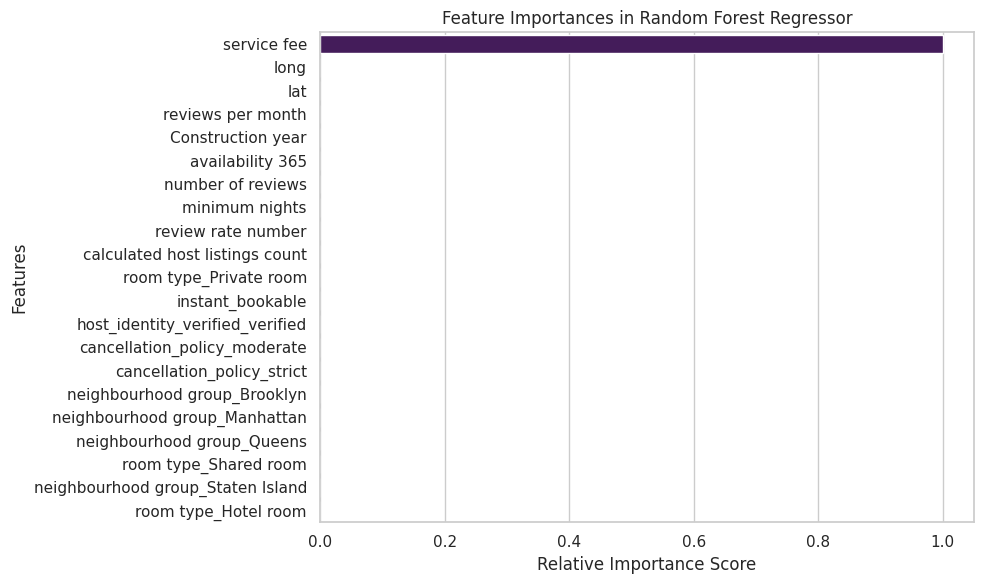

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Prepare Features and Target (Fixing the syntax 'column' -> 'columns')
X = df.drop(columns=['price'])
y = df['price']

# 2. Convert categorical columns safely before the split to keep features aligned
X = pd.get_dummies(X, drop_first=True)

# 3. Train-Test Split
X_train , X_test , y_train , y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4. Training the Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Make predictions & Evaluate
y_pred = model.predict(X_test)
score = r2_score(y_test, y_pred)
print(f"R2 Score: {score}")

# ==========================================
# VISUALIZE FEATURE IMPORTANCES
# ==========================================

# Extract feature importances and pair them with feature names
importances = model.feature_importances_
feature_names = X.columns

# Create a DataFrame to easily sort the values
forest_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
forest_importances = forest_importances.sort_values(by='Importance', ascending=False)

# Plot using Seaborn/Matplotlib
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=forest_importances, palette='viridis')

plt.title('Feature Importances in Random Forest Regressor')
plt.xlabel('Relative Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

### Explore which factors effect the availability

/tmp/ipykernel_4720/1452004421.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='room type', y='availability 365', ax=axes[0, 0], palette='muted')
/tmp/ipykernel_4720/1452004421.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='neighbourhood group', y='availability 365', ax=axes[0, 1], palette='magma')


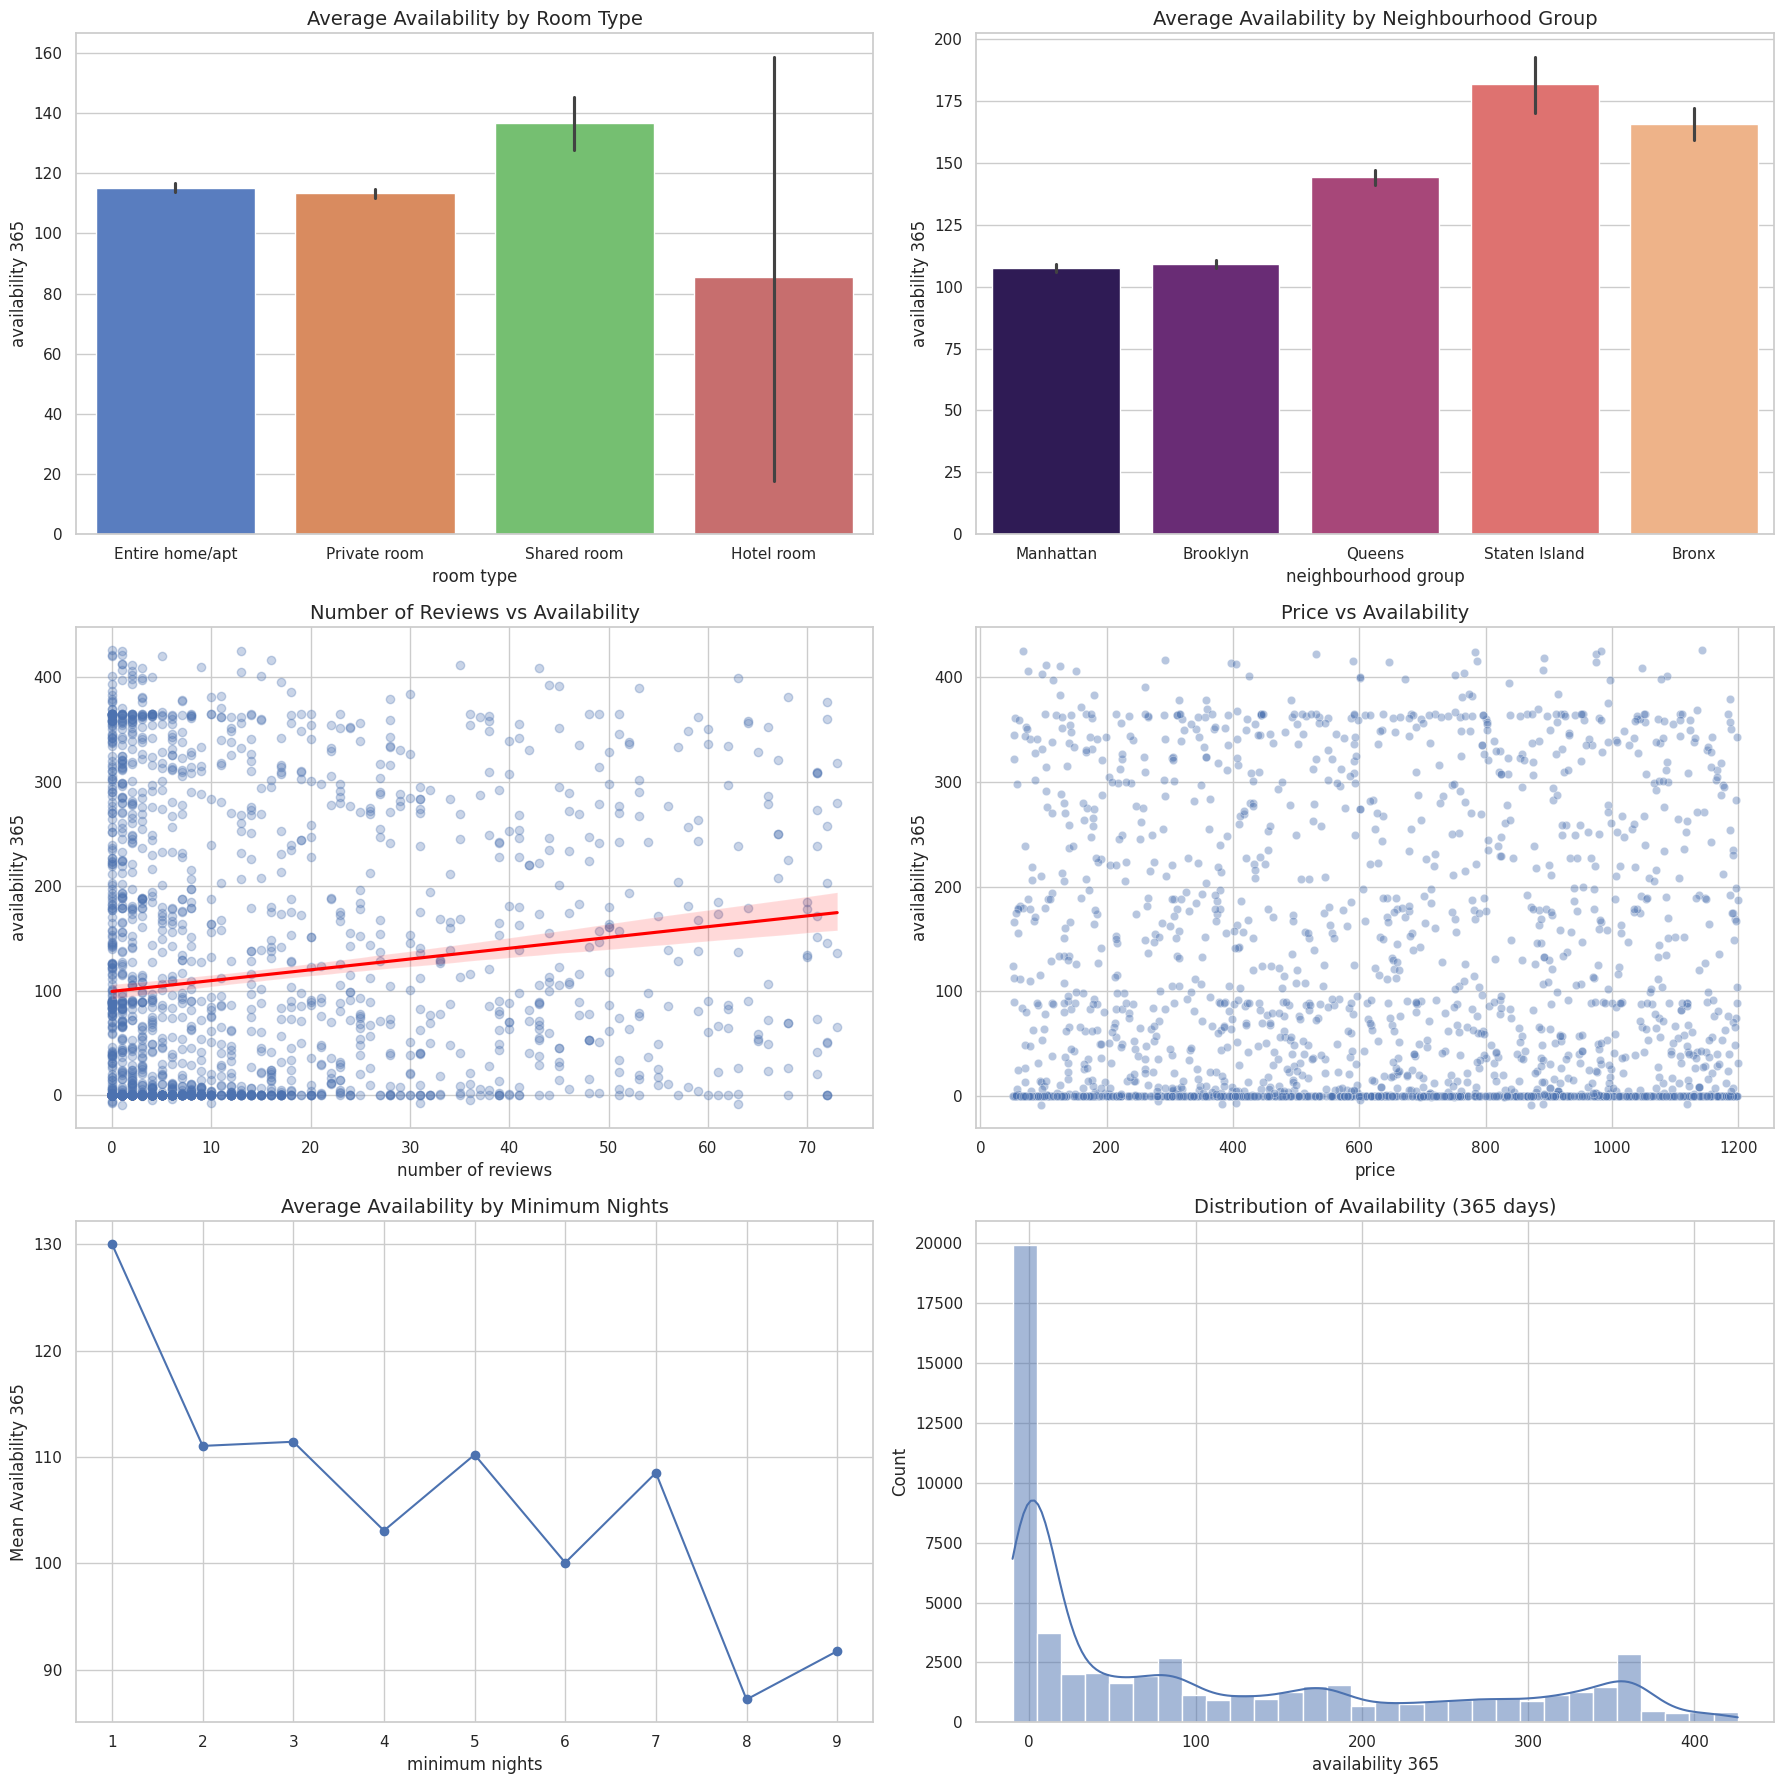

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(18, 18))

# 1. Availability by Room Type
sns.barplot(data=df, x='room type', y='availability 365', ax=axes[0, 0], palette='muted')
axes[0, 0].set_title('Average Availability by Room Type', fontsize=14)

# 2. Availability by Neighbourhood Group
sns.barplot(data=df, x='neighbourhood group', y='availability 365', ax=axes[0, 1], palette='magma')
axes[0, 1].set_title('Average Availability by Neighbourhood Group', fontsize=14)

# 3. Reviews vs Availability
# Using a regression plot (sampled for clarity) to see the trend
sns.regplot(data=df.sample(2000), x='number of reviews', y='availability 365',
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, ax=axes[1, 0])
axes[1, 0].set_title('Number of Reviews vs Availability', fontsize=14)

# 4. Price vs Availability
sns.scatterplot(data=df.sample(2000), x='price', y='availability 365', alpha=0.4, ax=axes[1, 1])
axes[1, 1].set_title('Price vs Availability', fontsize=14)

# 5. Minimum Nights vs Availability
# Grouping by minimum nights to see the mean trend
df.groupby('minimum nights')['availability 365'].mean().plot(kind='line', marker='o', ax=axes[2, 0])
axes[2, 0].set_title('Average Availability by Minimum Nights', fontsize=14)
axes[2, 0].set_ylabel('Mean Availability 365')

# 6. Distribution of Availability
sns.histplot(df['availability 365'], bins=30, kde=True, ax=axes[2, 1])
axes[2, 1].set_title('Distribution of Availability (365 days)', fontsize=14)

plt.tight_layout()
plt.show()

**1. Neighbourhood Group (`neighbourhood_group`)**

* **Observation:** There is a significant geographic disparity in availability across borough groups. High-demand central areas like **Manhattan** and **Brooklyn** show the lowest average availability (around **105–110 days** per year). In contrast, outer boroughs like **Staten Island** (~**180 days**) and **The Bronx** (~**165 days**) maintain much higher availability.
* **Impact:** Geographic demand is the strongest categorical driver of availability—listings in core metropolitan areas are booked far more frequently throughout the year.

**2. Number of Reviews (`number_of_reviews`)**

* **Observation:** The regression plot shows a distinct **positive linear trend** (red line rising from ~100 to over 170 days as reviews increase to 70+).
* **Impact:** Active, heavily-reviewed listings tend to be available for booking more days out of the year compared to low-review listings (many of which cluster at $0$ availability days).

**3. Minimum Nights (`minimum_nights`)**

* **Observation:** Average availability drops sharply from **130 days** at $1$ minimum night down to around **111 days** at $2$–$3$ nights, followed by a downward, fluctuating trend that reaches a low near **87 days** at $8$ minimum nights.
* **Impact:** Listings with strict, long-minimum-stay requirements (e.g., $8$–$9$ nights) generally record lower overall annual availability, likely reflecting lower turn-over flexibility or longer blockouts.

**4. Room Type (`room_type`)**

* **Observation:** **Shared rooms** have the highest average availability (~**135 days**), whereas **Entire home/apt** and **Private rooms** sit around **112–115 days**. **Hotel rooms** report a low average (~**85 days**) with extremely large confidence intervals/error bars due to small sample size or high variability.
* **Impact:** Shared rooms sit vacant for more days on average, while entire homes and private rooms face higher occupancy pressure.

**5. Price (`price`)**

* **Observation:** The scatter plot displays a completely uniform distribution across all price points ($50$ to $1200$).
* **Impact:** Price exhibits near-zero linear correlation with availability, meaning expensive listings are just as likely to be available (or unavailable) as budget listings.

In [46]:
df.sample(3)

,host_identity_verified,neighbourhood group,lat,long,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
20738,verified,Brooklyn,40.71975,-73.96136,True,strict,Entire home/apt,2022,923.0,185.0,2,10,0.69,4.0,1,0
21093,unconfirmed,Brooklyn,40.68432,-73.95150,False,strict,Entire home/apt,2011,598.0,120.0,2,3,0.23,2.0,1,0
42172,verified,Brooklyn,40.71492,-73.94332,True,flexible,Private room,2007,60.0,12.0,3,4,1.29,3.0,1,3


R2 Score: 0.3216559794741666


/tmp/ipykernel_4720/869863952.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=forest_importances, palette='viridis')


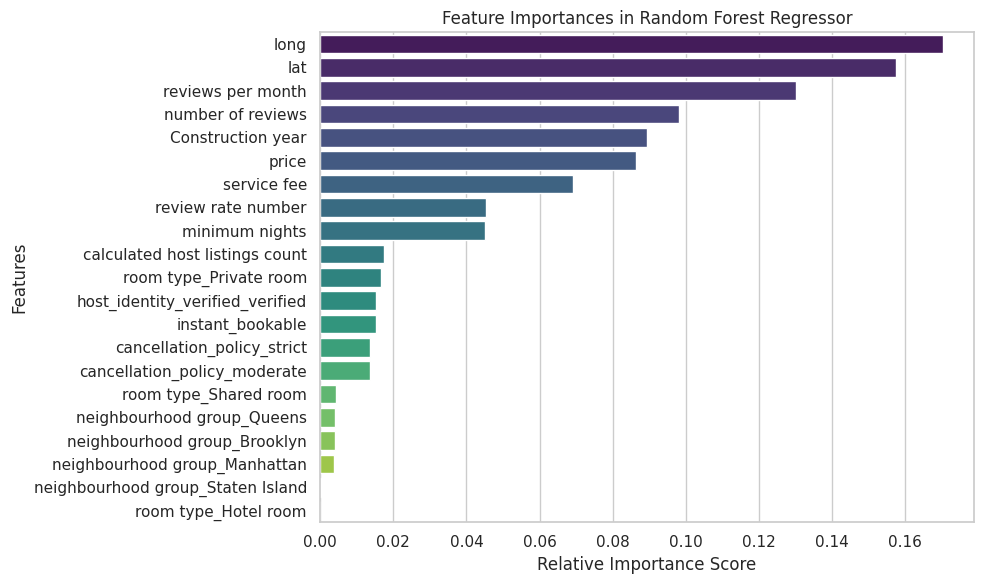

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Prepare Features and Target (Fixing the syntax 'column' -> 'columns')
X = df.drop(columns=['availability 365'])
y = df['availability 365']

# 2. Convert categorical columns safely before the split to keep features aligned
X = pd.get_dummies(X, drop_first=True)

# 3. Train-Test Split
X_train , X_test , y_train , y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4. Training the Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Make predictions & Evaluate
y_pred = model.predict(X_test)
score = r2_score(y_test, y_pred)
print(f"R2 Score: {score}")

# ==========================================
# VISUALIZE FEATURE IMPORTANCES
# ==========================================

# Extract feature importances and pair them with feature names
importances = model.feature_importances_
feature_names = X.columns

# Create a DataFrame to easily sort the values
forest_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
forest_importances = forest_importances.sort_values(by='Importance', ascending=False)

# Plot using Seaborn/Matplotlib
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=forest_importances, palette='viridis')

plt.title('Feature Importances in Random Forest Regressor')
plt.xlabel('Relative Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

The Random Forest model relies heavily on high-cardinality continuous variables to predict availability_365, with spatial coordinates (long at ~0.170 and lat at ~0.158) dominating the decision trees by capturing localized geographic clusters that linear models missed. Following location, operational activity metrics—specifically reviews per month (~0.130) and number of reviews (~0.098)—serve as primary indicators of listing engagement, while financial and structural features like construction year, price, and service fee provide secondary predictive power. In contrast, one-hot encoded categorical variables like specific neighborhood groups, room types, and cancellation policies contribute minimally (<0.02 each) due to feature sparsity, showing that fine-grained spatial and review dynamics far outweigh broad categorical labels when predicting annual availability.

### Explore factors are associated with reviews and ratings

/tmp/ipykernel_4720/97790697.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='review rate number', y='price', ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_4720/97790697.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='host_identity_verified', y='number of reviews', ax=axes[0, 1], palette='Set2')
/tmp/ipykernel_4720/97790697.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='room type', y='number of reviews', ax=axes[1, 1], palette='coolwarm')


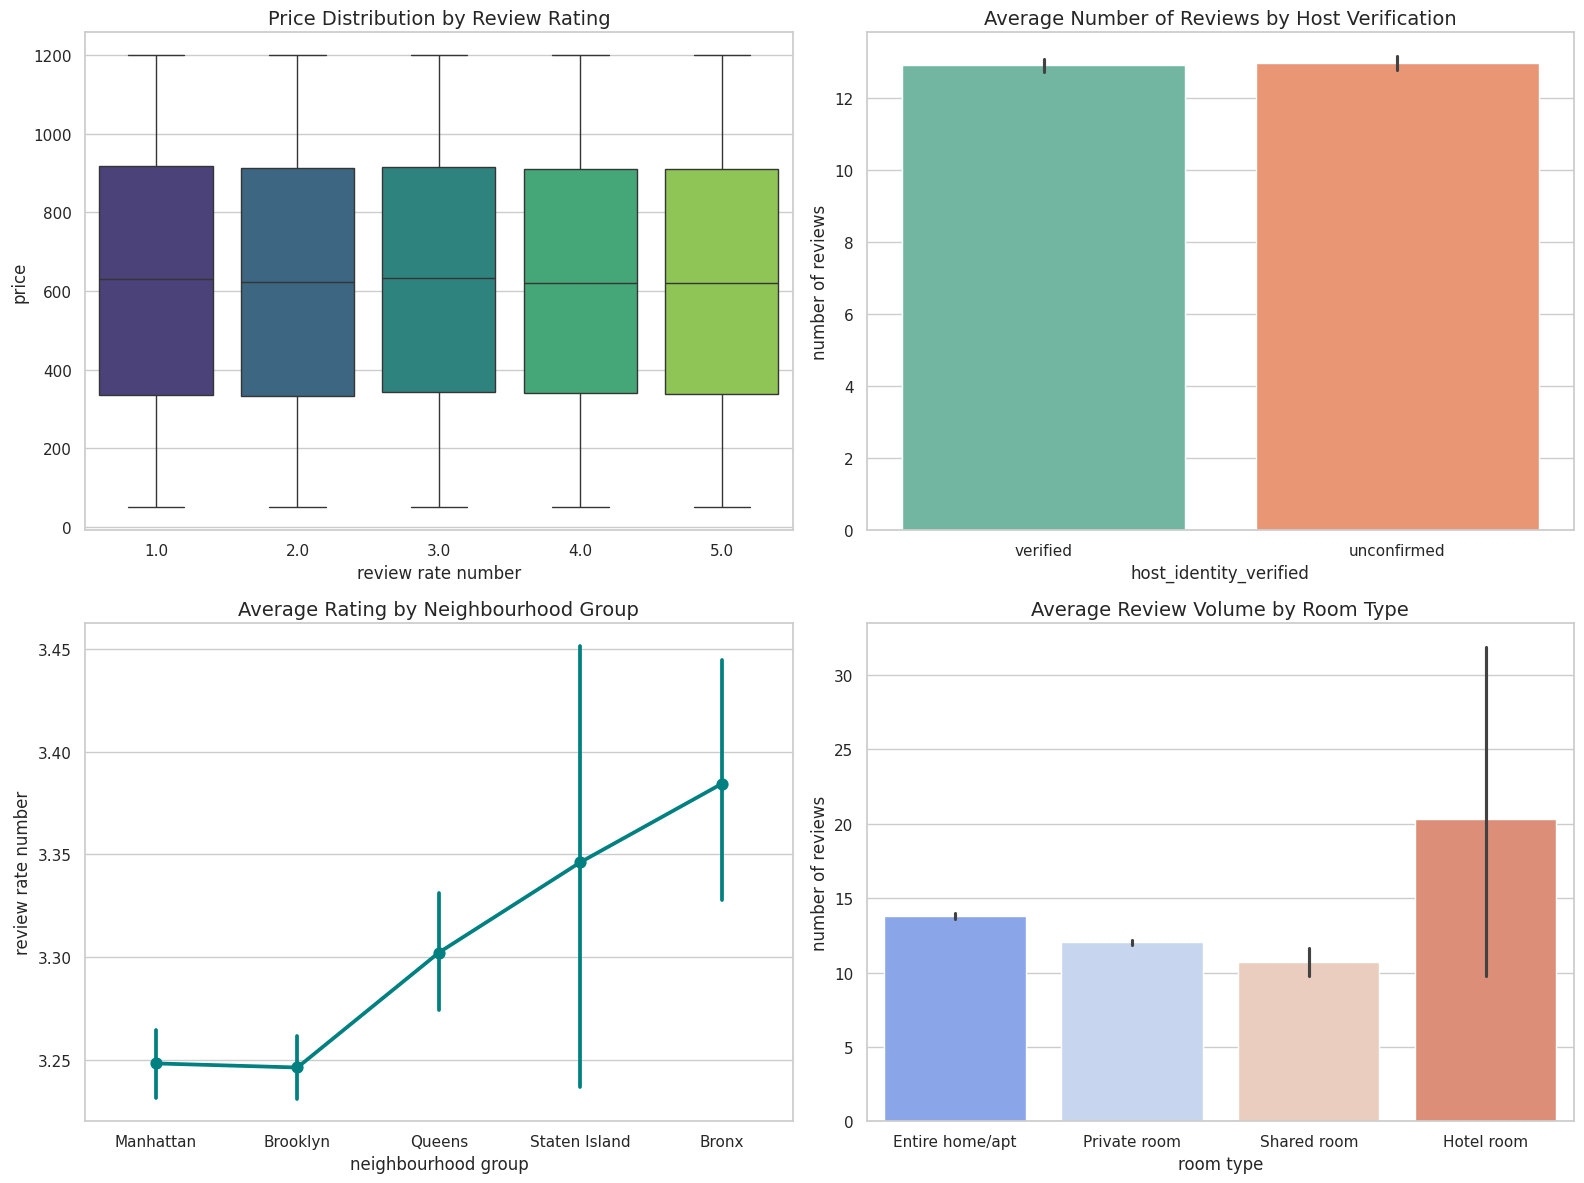

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set theme
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Price vs Review Rate Number (Do expensive listings get better ratings?)
sns.boxplot(data=df, x='review rate number', y='price', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Price Distribution by Review Rating', fontsize=14)

# 2. Host Identity Verified vs Number of Reviews (Does verification drive engagement?)
sns.barplot(data=df, x='host_identity_verified', y='number of reviews', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Average Number of Reviews by Host Verification', fontsize=14)

# 3. Neighbourhood Group vs Review Rate Number
sns.pointplot(data=df, x='neighbourhood group', y='review rate number', ax=axes[1, 0], color='teal')
axes[1, 0].set_title('Average Rating by Neighbourhood Group', fontsize=14)

# 4. Room Type vs Number of Reviews
sns.barplot(data=df, x='room type', y='number of reviews', ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title('Average Review Volume by Room Type', fontsize=14)

plt.tight_layout()
plt.show()

The four-panel visualization explores how pricing, verification status, location, and room types associate with user reviews and ratings. The box plot of Price Distribution by Review Rating demonstrates that price distributions remain completely static across all rating levels ($1.0$ through $5.0$), with medians fixed near $620$, indicating that higher listing prices do not correlate with superior guest ratings. Similarly, the Average Number of Reviews by Host Verification bar chart shows an identical average review count (~$13$ reviews) for both verified and unconfirmed hosts, proving that verification status does not drive guest feedback volume. Conversely, geographic location introduces distinct rating variations: the Average Rating by Neighbourhood Group plot displays a upward trend in average ratings from Manhattan and Brooklyn (~$3.25$) to Queens (~$3.30$), Staten Island (~$3.35$), and the Bronx (~$3.38$). Finally, the Average Review Volume by Room Type reveals that Hotel rooms generate the highest mean review volume (~$20$ reviews, albeit with large variance), outstripping Entire homes/apts (~$14$), Private rooms (~$12$), and Shared rooms (~$11$). Overall, while price and host verification show zero relationship with review metrics, geographical borough group and room category serve as key factors influencing guest rating levels and review activity.